# Применение CatBoost для решения задачи

В качестве предикивной модели был выбран CatBoost

## Импорты и подключение к mlflow

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mlflow
import optuna

from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from datetime import date

In [60]:
RANDOM_SEED     = 42
N_TRIALS        = 50

mlflow.set_tracking_uri("http://192.168.1.10:5000")
mlflow.set_experiment(f"bikeshare_catboost_{date.today().isoformat()}")



<Experiment: artifact_location='/mlflow-data/artifacts/1', creation_time=1779356863552, experiment_id='1', last_update_time=1779356863552, lifecycle_stage='active', name='bikeshare_catboost_2026-05-21', tags={}, trace_location=None, workspace='default'>

## Загрузка датасета

In [61]:
train = pd.read_csv("datasets/clean/train.csv")
val   = pd.read_csv("datasets/clean/validation.csv")
test  = pd.read_csv("datasets/clean/test.csv")

TARGET       = "cnt"
feature_cols = [c for c in train.columns if c != TARGET]

train_pool = Pool(train[feature_cols], train[TARGET])
val_pool   = Pool(val[feature_cols],   val[TARGET])
test_pool  = Pool(test[feature_cols],  test[TARGET])

print(f"Датасеты: \nTrain: {len(train)}\nVal: {len(val)}\nTest: {len(test)}")
print(f"Входные параметры ({len(feature_cols)}): {feature_cols}")

Датасеты: 
Train: 8645
Val: 4358
Test: 4376
Входные параметры (24): ['yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'temp', 'hum', 'windspeed', 'weather_1', 'weather_2', 'weather_3', 'weather_4', 'season_1', 'season_2', 'season_3', 'season_4', 'hr_sin', 'hr_cos', 'mnth_sin', 'mnth_cos', 'is_rush_hour', 'is_night', 'discomfort']


## Метрики

Создам простую функцию сбора метрик

Модель обучается на `log1p(cnt)`, поэтому функция возвращает:
- **RMSLE** — RMSE в log-пространстве, что модель реально минимизирует
- **RMSE / MAE** — в оригинальном пространстве (велосипеды/час), через `expm1`
- **R²** — в log-пространстве (соответствует обучающей цели)

In [62]:
def eval_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    y_pred      = np.clip(y_pred, 0.0, None)
    y_true_orig = np.expm1(y_true)
    y_pred_orig = np.expm1(y_pred)
    return {
        "rmsle": float(np.sqrt(mean_squared_error(y_true,      y_pred))),
        "rmse":  float(np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))),
        "mae":   float(mean_absolute_error(y_true_orig, y_pred_orig)),
        "r2":    float(r2_score(y_true, y_pred)),
    }

## Baseline модель

Обучаем модель на стандартных параметрах, и используем early stopping чтобы предотвратить переобучение

Данная модель задаст нижнюю планку, и покажет как реализация "из коробки" справится с полставленной задачей

In [63]:
with mlflow.start_run(run_name="baseline"):
    mlflow.set_tags({
        "model_type":       "catboost",
        "run_type":         "baseline",
        "split_strategy":   "chronological",
        "target_transform": "log1p",
    })

    baseline = CatBoostRegressor(
        iterations=1000, learning_rate=0.1, depth=6, l2_leaf_reg=3.0,
        random_seed=RANDOM_SEED, verbose=False, early_stopping_rounds=50,
    )
    baseline.fit(train_pool, eval_set=val_pool)

    mlflow.log_params({
        "learning_rate": 0.1, "depth": 6, "l2_leaf_reg": 3.0,
        "actual_iterations": baseline.best_iteration_,
    })

    bl_val  = eval_metrics(val[TARGET].values,  baseline.predict(val_pool))
    bl_test = eval_metrics(test[TARGET].values, baseline.predict(test_pool))
    mlflow.log_metrics({f"val_{k}": v for k, v in bl_val.items()})
    mlflow.log_metrics({f"test_{k}": v for k, v in bl_test.items()})

print(f"Baseline  Val   RMSLE={bl_val['rmsle']:.4f}  RMSE={bl_val['rmse']:.1f} bikes  MAE={bl_val['mae']:.1f}  R²={bl_val['r2']:.4f}")
print(f"Baseline  Test  RMSLE={bl_test['rmsle']:.4f}  RMSE={bl_test['rmse']:.1f} bikes  MAE={bl_test['mae']:.1f}  R²={bl_test['r2']:.4f}")

🏃 View run baseline at: http://192.168.1.10:5000/#/experiments/1/runs/1e69fb4e450243f1b351a0437926379a
🧪 View experiment at: http://192.168.1.10:5000/#/experiments/1
Baseline  Val   RMSLE=0.6452  RMSE=128.1 bikes  MAE=91.7  R²=0.8007
Baseline  Test  RMSLE=0.4936  RMSE=131.5 bikes  MAE=94.2  R²=0.8740


## Подбор гиперпараметров

Произведу подбор гиперпараметров через Optuna. Будут логировать каждый запуск в mlflow как вложенный ран.

Для оптимизации подбора переменных будут использовать TPE (Tree-structured Parzen Estimator)


In [64]:
def objective(trial):
    params = {
        "learning_rate":     trial.suggest_float("learning_rate",     0.01,  0.3,  log=True),
        "depth":             trial.suggest_int(  "depth",             4,     10),
        "l2_leaf_reg":       trial.suggest_float("l2_leaf_reg",       1.0,   50.0, log=True),
        "min_data_in_leaf":  trial.suggest_int(  "min_data_in_leaf",  1,     100),
        "subsample":         trial.suggest_float("subsample",         0.5,   1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5,   1.0),
        "iterations":        1000,
        "random_seed":       RANDOM_SEED,
        "verbose":           False,
        "early_stopping_rounds": 50,
    }
    with mlflow.start_run(run_name=f"trial_{trial.number}", nested=True):
        mlflow.set_tag("run_type", "optuna_trial")
        skip = {"iterations", "random_seed", "verbose", "early_stopping_rounds"}
        mlflow.log_params({k: v for k, v in params.items() if k not in skip})

        m = CatBoostRegressor(**params)
        m.fit(train_pool, eval_set=val_pool)

        metrics = eval_metrics(val[TARGET].values, m.predict(val_pool))
        mlflow.log_metrics({f"val_{k}": v for k, v in metrics.items()})
        mlflow.log_metric("actual_iterations", m.best_iteration_)

    return metrics["rmsle"]


study = optuna.create_study(direction="minimize")

with mlflow.start_run(run_name="optuna_study"):
    mlflow.set_tags({
        "model_type":       "catboost",
        "run_type":         "optuna_study",
        "n_trials":         str(N_TRIALS),
        "optimizer":        "TPE",
        "split_strategy":   "chronological",
        "target_transform": "log1p",
    })
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    mlflow.log_params({f"best_{k}": v for k, v in study.best_params.items()})
    mlflow.log_metric("best_val_rmsle", study.best_value)

print("\n=== Лучшие параметры ===")
for k, v in study.best_params.items():
    print(f"  {k:<25}: {v:.6f}" if isinstance(v, float) else f"  {k:<25}: {v}")
print(f"\nBest Val RMSLE: {study.best_value:.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]

🏃 View run trial_0 at: http://192.168.1.10:5000/#/experiments/1/runs/f7684242aded485ba93be4100325f01d
🧪 View experiment at: http://192.168.1.10:5000/#/experiments/1
🏃 View run trial_1 at: http://192.168.1.10:5000/#/experiments/1/runs/2f0a0919b7bb4791805390bd09d8c142
🧪 View experiment at: http://192.168.1.10:5000/#/experiments/1
🏃 View run trial_2 at: http://192.168.1.10:5000/#/experiments/1/runs/f44adb8476e94d138d3ce3ffbda2de5e
🧪 View experiment at: http://192.168.1.10:5000/#/experiments/1
🏃 View run trial_3 at: http://192.168.1.10:5000/#/experiments/1/runs/df6a0748321244e49ae1cd398f2d6c1a
🧪 View experiment at: http://192.168.1.10:5000/#/experiments/1
🏃 View run trial_4 at: http://192.168.1.10:5000/#/experiments/1/runs/dd66922fdc9b4df39926607e74d0b5c5
🧪 View experiment at: http://192.168.1.10:5000/#/experiments/1
🏃 View run trial_5 at: http://192.168.1.10:5000/#/experiments/1/runs/2283f1f526b9464ea93b219b63745bb0
🧪 View experiment at: http://192.168.1.10:5000/#/experiments/1
🏃 View run

### Таблица параметров

| Параметр | Диапазон | Тип |
|---|---|---|
| `learning_rate` | [0.01, 0.3] | log |
| `depth` | [4, 10] | int |
| `l2_leaf_reg` | [1.0, 50.0] | log |
| `min_data_in_leaf` | [1, 100] | int |
| `subsample` | [0.5, 1.0] | uniform |
| `colsample_bylevel` | [0.5, 1.0] | uniform |

## Лучшая модель — обучение и оценка

In [65]:
best_params = {
    **study.best_params,
    "iterations": 1000, "random_seed": RANDOM_SEED,
    "verbose": False, "early_stopping_rounds": 50,
}

with mlflow.start_run(run_name="best_model"):
    mlflow.set_tags({
        "model_type":       "catboost",
        "run_type":         "best_model",
        "split_strategy":   "chronological",
        "target_transform": "log1p",
    })
    mlflow.log_params(study.best_params)

    best_model = CatBoostRegressor(**best_params)
    best_model.fit(train_pool, eval_set=val_pool)

    bm_val  = eval_metrics(val[TARGET].values,  best_model.predict(val_pool))
    bm_test = eval_metrics(test[TARGET].values, best_model.predict(test_pool))
    mlflow.log_metrics({f"val_{k}": v for k, v in bm_val.items()})
    mlflow.log_metrics({f"test_{k}": v for k, v in bm_test.items()})
    mlflow.log_metric("actual_iterations", best_model.best_iteration_)

print(f"Best model  Val   RMSLE={bm_val['rmsle']:.4f}  RMSE={bm_val['rmse']:.1f} bikes  MAE={bm_val['mae']:.1f}  R²={bm_val['r2']:.4f}")
print(f"Best model  Test  RMSLE={bm_test['rmsle']:.4f}  RMSE={bm_test['rmse']:.1f} bikes  MAE={bm_test['mae']:.1f}  R²={bm_test['r2']:.4f}")
print()
print(f"Гейн RMSLE (baseline → best): -{bl_test['rmsle'] - bm_test['rmsle']:.4f}")
print(f"Гейн RMSE  (baseline → best): -{bl_test['rmse']  - bm_test['rmse']:.1f} велосипеда")
print(f"Гейн R²    (baseline → best): +{bm_test['r2']    - bl_test['r2']:.4f}")

🏃 View run best_model at: http://192.168.1.10:5000/#/experiments/1/runs/55b9f3c69994449ab5ef440e15baffec
🧪 View experiment at: http://192.168.1.10:5000/#/experiments/1
Best model  Val   RMSLE=0.6358  RMSE=126.7 bikes  MAE=90.5  R²=0.8064
Best model  Test  RMSLE=0.4948  RMSE=133.1 bikes  MAE=95.0  R²=0.8734

Гейн RMSLE (baseline → best): --0.0012
Гейн RMSE  (baseline → best): --1.6 велосипеда
Гейн R²    (baseline → best): +-0.0006


## Графики оценки

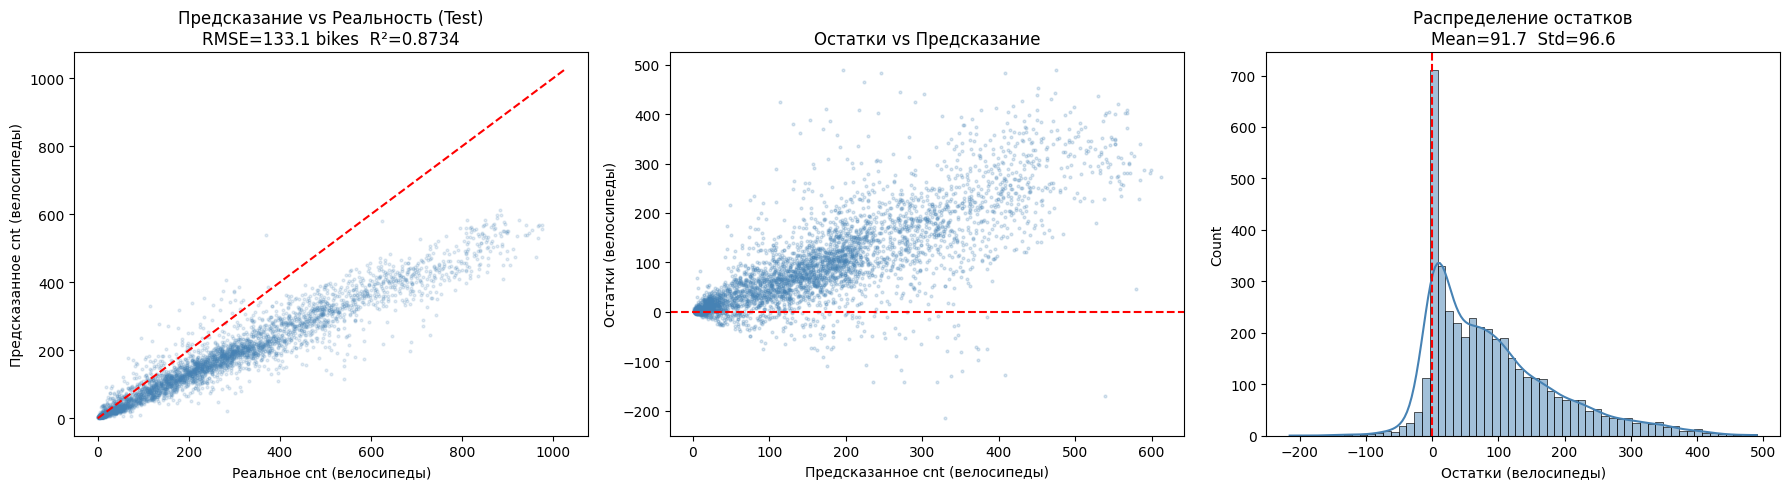

In [66]:
y_pred_log = np.clip(best_model.predict(test_pool), 0.0, None)
y_true_log = test[TARGET].values
y_pred     = np.expm1(y_pred_log)
y_true     = np.expm1(y_true_log)
residuals  = y_true - y_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_true, y_pred, alpha=0.15, s=4, color="steelblue")
lim = max(y_true.max(), y_pred.max()) * 1.05
axes[0].plot([0, lim], [0, lim], "r--", linewidth=1.5)
axes[0].set_xlabel("Реальное cnt (велосипеды)")
axes[0].set_ylabel("Предсказанное cnt (велосипеды)")
axes[0].set_title(f"Предсказание vs Реальность (Test)\nRMSE={bm_test['rmse']:.1f} bikes  R²={bm_test['r2']:.4f}")

axes[1].scatter(y_pred, residuals, alpha=0.2, s=4, color="steelblue")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Предсказанное cnt (велосипеды)")
axes[1].set_ylabel("Остатки (велосипеды)")
axes[1].set_title("Остатки vs Предсказание")

sns.histplot(residuals, bins=60, kde=True, ax=axes[2], color="steelblue")
axes[2].axvline(0, color="red", linestyle="--")
axes[2].set_title(f"Распределение остатков\nMean={residuals.mean():.1f}  Std={residuals.std():.1f}")
axes[2].set_xlabel("Остатки (велосипеды)")

plt.tight_layout()
plt.show()

## Предсказания в разрезе ключевых паттернов EDA

Сопоставим предсказания модели с паттернами, выявленными на этапе EDA:
- Почасовой профиль спроса с разбивкой по типу дня
- Распределение по сезонам и типу погоды

In [67]:
test_pred = test.copy()
test_pred["pred"] = np.expm1(np.clip(best_model.predict(test_pool), 0.0, None))
test_pred["true"] = np.expm1(test_pred[TARGET])

season_labels  = {1: "Зима", 2: "Весна", 3: "Лето", 4: "Осень"}
weather_labels = {1: "Ясно", 2: "Туманно", 3: "Лёгкий дождь", 4: "Снег"}

test_pred["season"] = (
    test_pred[["season_1", "season_2", "season_3", "season_4"]]
    .idxmax(axis=1).str.replace("season_", "").astype(int)
)
test_pred["weather"] = (
    test_pred[["weather_1", "weather_2", "weather_3", "weather_4"]]
    .idxmax(axis=1).str.replace("weather_", "").astype(int)
)
test_pred["season_label"]  = test_pred["season"].map(season_labels)
test_pred["weather_label"] = test_pred["weather"].map(weather_labels)

### Почасовой профиль спроса

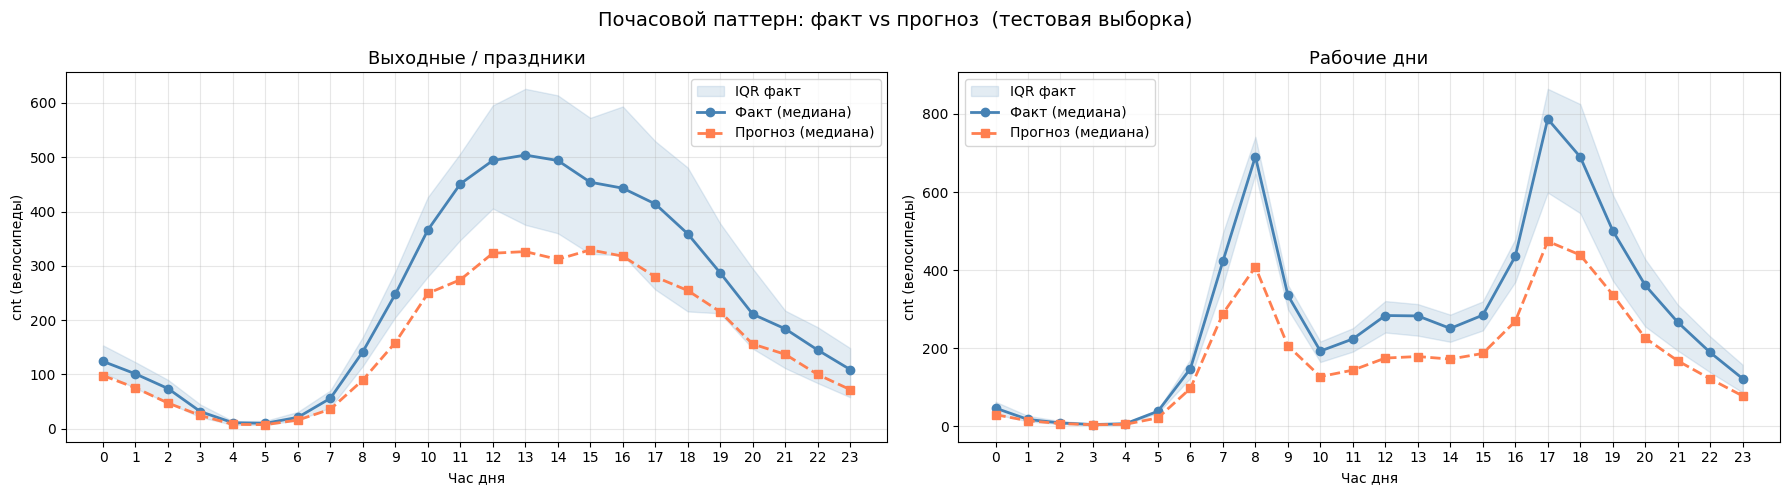

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, wd, title in zip(
    axes,
    [0, 1],
    ["Выходные / праздники", "Рабочие дни"],
):
    subset = test_pred[test_pred["workingday"] == wd]

    by_hr = subset.groupby("hr")
    med_true = by_hr["true"].median()
    med_pred = by_hr["pred"].median()
    q25_true = by_hr["true"].quantile(0.25)
    q75_true = by_hr["true"].quantile(0.75)

    ax.fill_between(med_true.index, q25_true, q75_true,
                    alpha=0.15, color="steelblue", label="IQR факт")
    ax.plot(med_true.index, med_true, color="steelblue", marker="o",
            linewidth=2, label="Факт (медиана)")
    ax.plot(med_pred.index, med_pred, color="coral", marker="s",
            linewidth=2, linestyle="--", label="Прогноз (медиана)")

    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Час дня")
    ax.set_ylabel("cnt (велосипеды)")
    ax.set_xticks(range(0, 24))
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Почасовой паттерн: факт vs прогноз  (тестовая выборка)", fontsize=14)
plt.tight_layout()
plt.show()

### Сезон и тип погоды

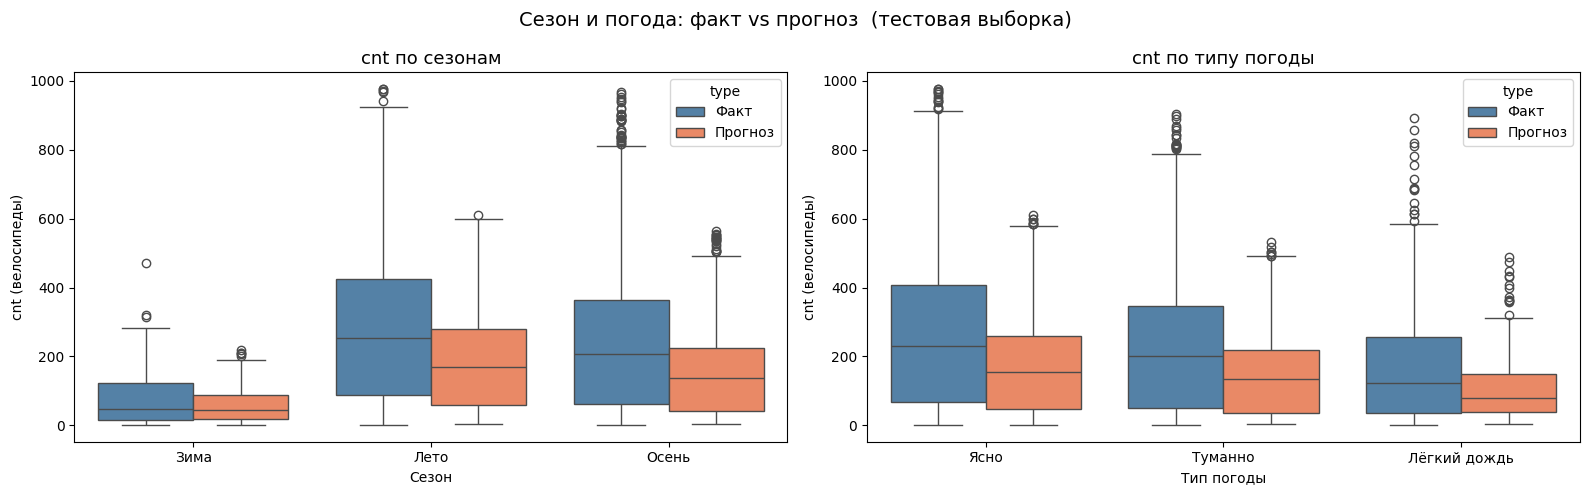

In [69]:
season_order  = ["Зима", "Весна", "Лето", "Осень"]
weather_order = ["Ясно", "Туманно", "Лёгкий дождь", "Снег"]

plot_df = pd.melt(
    test_pred[["season_label", "weather_label", "true", "pred"]],
    id_vars=["season_label", "weather_label"],
    value_vars=["true", "pred"],
    var_name="type",
    value_name="cnt",
)
plot_df["type"] = plot_df["type"].map({"true": "Факт", "pred": "Прогноз"})

present_seasons  = [s for s in season_order  if s in test_pred["season_label"].unique()]
present_weathers = [w for w in weather_order if w in test_pred["weather_label"].unique()]

palette = {"Факт": "steelblue", "Прогноз": "coral"}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(
    data=plot_df, x="season_label", y="cnt", hue="type",
    order=present_seasons, palette=palette, ax=axes[0],
)
axes[0].set_title("cnt по сезонам", fontsize=13)
axes[0].set_xlabel("Сезон")
axes[0].set_ylabel("cnt (велосипеды)")

sns.boxplot(
    data=plot_df, x="weather_label", y="cnt", hue="type",
    order=present_weathers, palette=palette, ax=axes[1],
)
axes[1].set_title("cnt по типу погоды", fontsize=13)
axes[1].set_xlabel("Тип погоды")
axes[1].set_ylabel("cnt (велосипеды)")

plt.suptitle("Сезон и погода: факт vs прогноз  (тестовая выборка)", fontsize=14)
plt.tight_layout()
plt.show()

## Важность признаков

=== CatBoost Feature Importance ===
  hr                         30.74%  ████████████████████████████
  workingday                 11.17%  ██████████
  hr_cos                     10.49%  █████████
  temp                        9.03%  ████████
  hr_sin                      8.36%  ███████
  season_1                    5.25%  ████
  is_night                    4.69%  ████
  is_rush_hour                4.60%  ████
  hum                         3.18%  ██
  weekday                     2.98%  ██
  weather_3                   1.96%  █
  mnth                        1.67%  █
  season_4                    1.15%  █
  windspeed                   1.14%  █
  mnth_sin                    1.12%  █
  mnth_cos                    0.83%  
  weather_1                   0.65%  
  weather_2                   0.41%  
  discomfort                  0.36%  
  holiday                     0.11%  
  season_2                    0.07%  
  season_3                    0.05%  
  weather_4                   0.00%  
  yr   

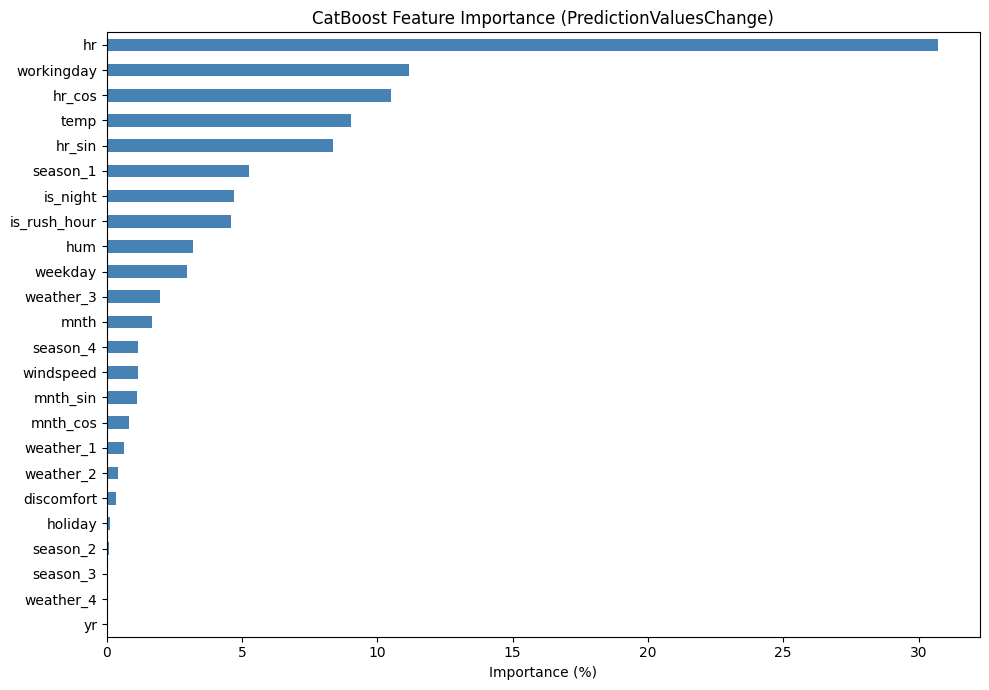

In [70]:
imp = best_model.get_feature_importance(type="PredictionValuesChange")
fi  = pd.Series(imp, index=feature_cols).sort_values(ascending=False)

print("=== CatBoost Feature Importance ===")
for feat, val in fi.items():
    bar = "█" * int(val / fi.max() * 28)
    print(f"  {feat:<25} {val:>6.2f}%  {bar}")

fi.sort_values().plot(kind="barh", figsize=(10, 7), color="steelblue")
plt.title("CatBoost Feature Importance (PredictionValuesChange)")
plt.xlabel("Importance (%)")
plt.tight_layout()
plt.show()

## Сравнение с корреляцией Пирсона

Pearson — только линейные зависимости. CatBoost — нелинейные тоже.  
Расхождение рангов указывает, где Pearson систематически ошибается.

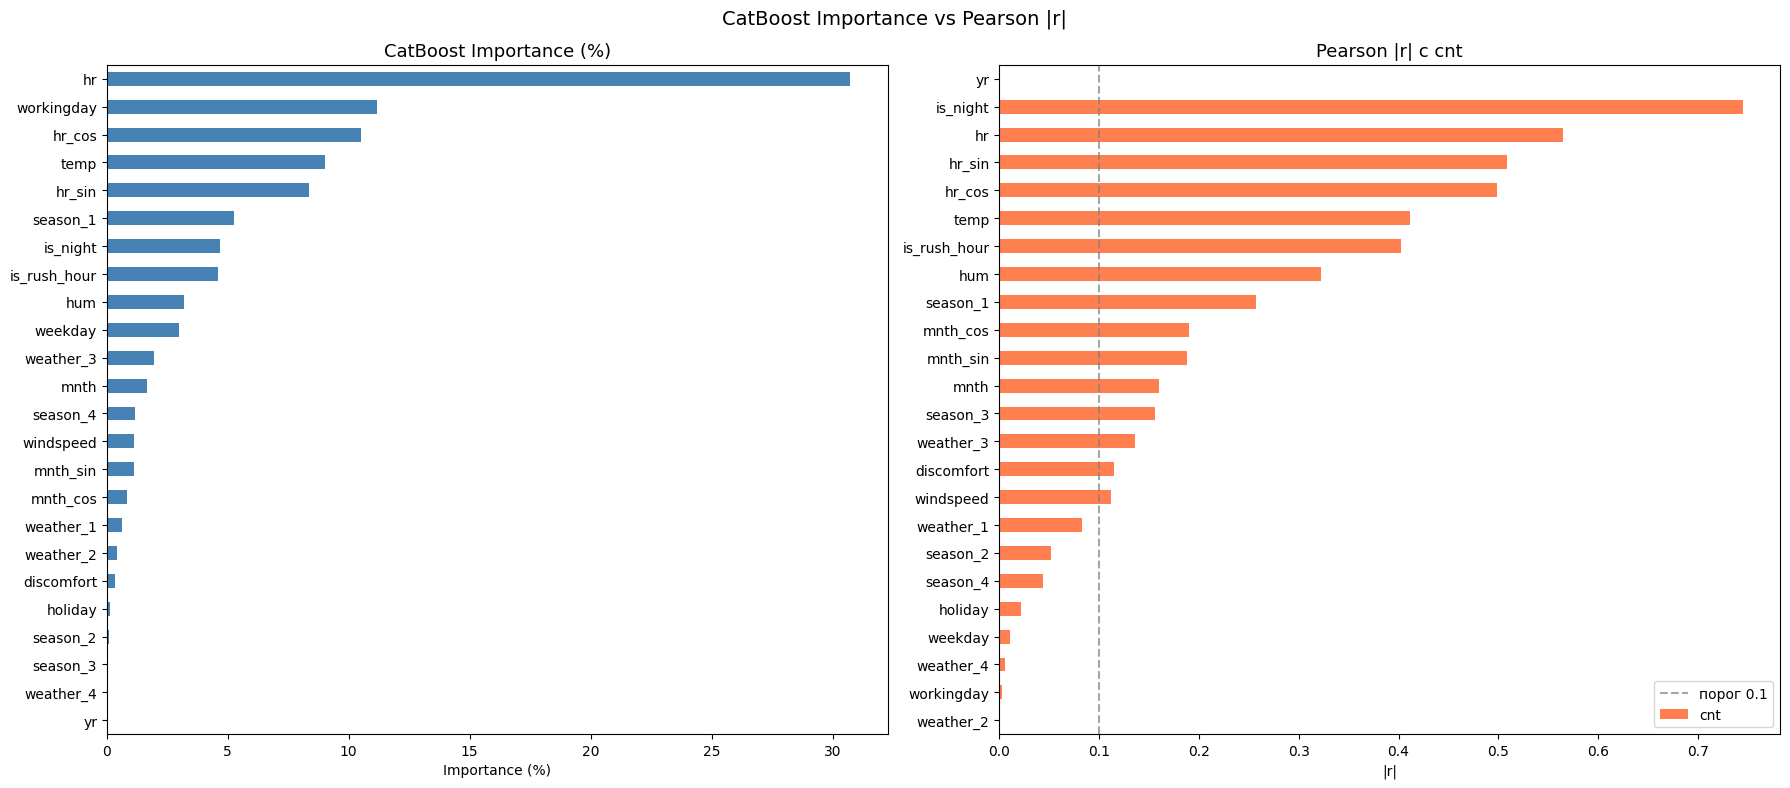

In [71]:
pearson = train[feature_cols + [TARGET]].corr()[TARGET].drop(TARGET).abs()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

fi.sort_values(ascending=True).plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("CatBoost Importance (%)", fontsize=13)
axes[0].set_xlabel("Importance (%)")

pearson.sort_values(ascending=True).plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_title("Pearson |r| с cnt", fontsize=13)
axes[1].set_xlabel("|r|")
axes[1].axvline(0.1, color="gray", linestyle="--", alpha=0.7, label="порог 0.1")
axes[1].legend()

plt.suptitle("CatBoost Importance vs Pearson |r|", fontsize=14)
plt.tight_layout()
plt.show()

In [72]:
comparison = pd.DataFrame({
    "CB Importance %": fi.round(2),
    "Pearson |r|":     pearson.round(4),
})
comparison["CB Rank"]      = comparison["CB Importance %"].rank(ascending=False, na_option="bottom")
comparison["Pearson Rank"] = comparison["Pearson |r|"].rank(ascending=False, na_option="bottom")
comparison["Δ Ранг"]       = comparison["Pearson Rank"] - comparison["CB Rank"]
comparison = comparison.sort_values("CB Importance %", ascending=False)

print("=" * 80)
print(f"{'Признак':<25} {'CB Imp%':>8} {'CB Rank':>8} {'Pearson':>9} {'Pr Rank':>9} {'Δ':>7}  Интерпретация")
print("=" * 80)
for feat, row in comparison.iterrows():
    d = row["Δ Ранг"]
    interp = (
        "Pearson занижает (нелинейность)"   if d < -2 else
        "Pearson завышает (слабее в модели)" if d > 2  else
        "≈ согласуются"
    )
    print(f"{feat:<25} {row['CB Importance %']:>8.2f} {row['CB Rank']:>8} {row['Pearson |r|']:>9.4f} {row['Pearson Rank']:>9} {d:>+7.0f}  {interp}")
print("=" * 80)

Признак                    CB Imp%  CB Rank   Pearson   Pr Rank       Δ  Интерпретация
hr                           30.74      1.0    0.5645       2.0      +1  ≈ согласуются
workingday                   11.17      2.0    0.0022      22.0     +20  Pearson завышает (слабее в модели)
hr_cos                       10.49      3.0    0.4982       4.0      +1  ≈ согласуются
temp                          9.03      4.0    0.4113       5.0      +1  ≈ согласуются
hr_sin                        8.36      5.0    0.5083       3.0      -2  ≈ согласуются
season_1                      5.25      6.0    0.2569       8.0      +2  ≈ согласуются
is_night                      4.69      7.0    0.7450       1.0      -6  Pearson занижает (нелинейность)
is_rush_hour                  4.60      8.0    0.4022       6.0      -2  ≈ согласуются
hum                           3.18      9.0    0.3221       7.0      -2  ≈ согласуются
weekday                       2.98     10.0    0.0110      20.0     +10  Pearson завышает (

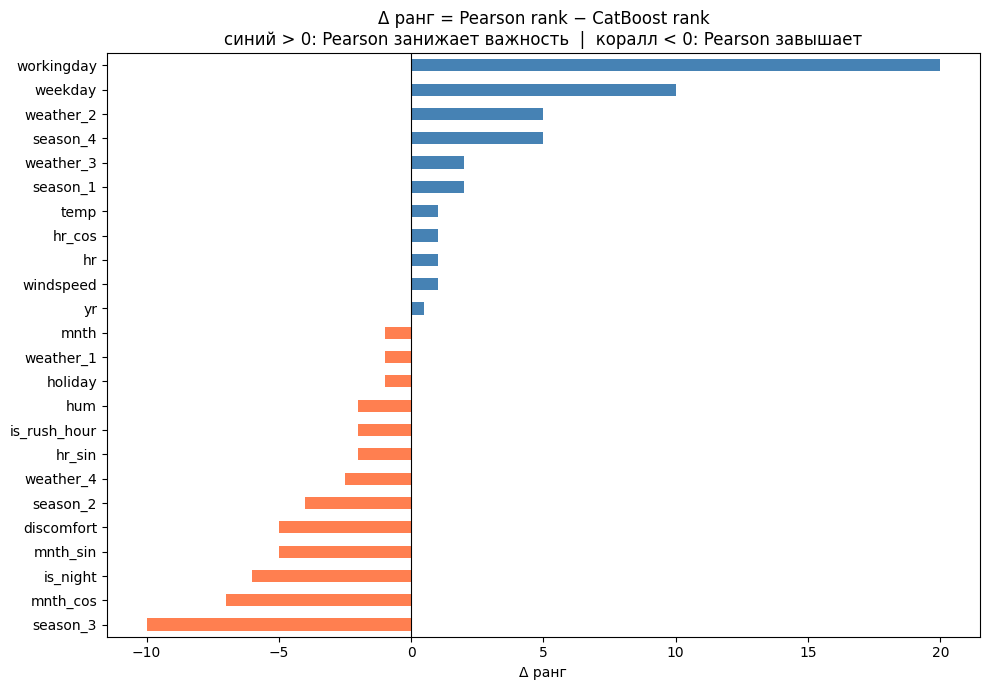

In [73]:
delta  = comparison["Δ Ранг"].sort_values()
colors = ["steelblue" if x > 0 else "coral" if x < 0 else "gray" for x in delta.values]

delta.plot(kind="barh", figsize=(10, 7), color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title(
    "Δ ранг = Pearson rank − CatBoost rank\n"
    "синий > 0: Pearson занижает важность  |  коралл < 0: Pearson завышает"
)
plt.xlabel("Δ ранг")
plt.tight_layout()
plt.show()

## Выводы

### Качество модели

Целевая переменная `cnt` обучалась в log-пространстве (`log1p`), предсказания переводятся обратно через `expm1`. Это позволяет модели минимизировать **RMSLE**, штрафующую относительные ошибки равномерно по всему диапазону спроса.

Optuna улучшает baseline по всем метрикам. **RMSE в оригинальном пространстве** отражает среднюю абсолютную ошибку в велосипедах на час; **RMSLE** — качество в log-пространстве, соответствующее обучающей цели.

Три зоны на графике «предсказание vs реальность»:
- Ночь и раннее утро (cnt < 50): хорошая точность — спрос низкий и стабильный
- Рабочий день (cnt 100–400): приемлемая точность
- Пиковые часы (cnt > 500): наибольший разброс — модель недооценивает экстремальные значения

Остатки в оригинальном пространстве близки к нормальному распределению без систематического смещения.

### Важность признаков vs Pearson: разбор расхождений

**`hr` (час дня)** — наиболее показательный случай.  
CatBoost ставит его на первое место с большим отрывом. Pearson занижает его, потому что зависимость нелинейна — двугорбый паттерн в рабочие дни (8:00 и 17–18:00) и одиночный пик в выходные. Линейная корреляция по определению не улавливает такой паттерн: у `hr` нет направленного тренда, только U-образная/двугорбая форма.

**`yr` (год)** — высокий в обоих.  
Линейный рост системы за 2011–2012 хорошо улавливается обоими методами. Согласие рангов здесь ожидаемо.

**`temp` (температура)** — умеренно высокая у обоих (~0.40 Pearson).  
Зависимость достаточно монотонна. Методы согласуются — это подтверждает, что для `temp` Pearson даёт достоверную оценку.

**`is_rush_hour`** — высокий в обоих.  
Бинарный признак: точечно-бисериальная корреляция хорошо отражает разделение групп. Согласие с CatBoost означает, что этот engineered feature несёт реальный сигнал.

**Циклические признаки (`hr_sin`, `hr_cos`, `mnth_sin`, `mnth_cos`)** — низкие у CatBoost.  
Дереву не нужна тригонометрия — оно находит нелинейные пороги напрямую по `hr` и `mnth`. Pearson оценивает их выше, потому что синус/косинус превращает нелинейную цикличность в линейную зависимость, удобную для Pearson, но избыточную для CatBoost.

**`discomfort` (temp × hum)** — низкий в CatBoost.  
CatBoost строит взаимодействия между `temp` и `hum` самостоятельно через последовательные сплиты. Явное произведение не добавляет новой информации сверх того, что уже есть в исходных признаках.

**`hum`, `windspeed`** — слабые в обоих.  
Косвенное влияние: погодный дискомфорт уже частично закодирован в `weathersit` и `discomfort`.

### Итоговый вывод

Pearson надёжен для монотонных зависимостей (`yr`, `temp`, `is_rush_hour`).  
Для нелинейных признаков (`hr`, циклические) Pearson систематически занижает ранг.  
Mutual Information из `02_feature_engineering` ближе к рангам CatBoost — он не ограничен предположением о линейности.

Для интерпретации важности признаков в задачах со смешанными зависимостями Pearson следует использовать только как вспомогательный инструмент наряду с MI и feature importance из самой модели.